# SimIM Simulation Interface Demo
One of SimIM's features is a uniform format for cosmological simulations. Once simulations are 
written into this format the ``simim.siminterface`` package can interface with any simulation
in a homogeneous manner.

Currently SimIM has support for the Illustris and Illustris TNG simulations, as well as the 
UniverseMachine fiducial halo/galaxy catalogs. Adding additonal simulations requires new code
but is relatively straightforward.

Here we will interface with the TNG100-3-Dark simulation. This is a simulation box with 100 Mpc 
sides, a dark matter particle mass of $4\times10^8$ $M_\odot$, and no Baryonic physics. We use
this simulation because the total data volume is relatively small (~3 GB compared to ~1 TB for
the full physics, full resolution TNG300-1 simulation), but do check that you have space for 3 GB
of data before running this demo. Details about the simulation can be found here: 
https://www.tng-project.org/data/downloads/TNG100-1-Dark/

In [1]:
import numpy as np
import simim.siminterface as sim

If this is your first time using SimIM on a machine, 
uncomment and run the following lines and follow the prompts

In [2]:
# from simim.setup import create_paths
# create_paths()

## Downloading and Formatting a Simulation
We'll start by getting the TNG100-3-Dark simulation. Note that this is a large
quantity of data and will take some time depending on your internet connection.
This initial download is in the raw format provided by the original halo catalogs,
we will translate it to SimIM's format in a second step.

In [8]:
# download the data - set the redownload parameter to True
# if you want to overwrite snapshots already saved on your 
# machine.

cat = sim.illustris.illustris_catalogs('TNG100-3-Dark')
cat.download_meta(redownload=False)
cat.download(redownload=False)

/global/cfs/cdirs/des/shubh/timsim/simim/simim/siminterface/illustris.py:308: UserWarning: Metadata appears to exist already
  warnings.warn("Metadata appears to exist already")
/global/cfs/cdirs/des/shubh/timsim/simim/simim/siminterface/illustris.py:259: UserWarning: Skipping snapshot 0 as it appears to exist already
  warnings.warn("Skipping snapshot {} as it appears to exist already".format(i))
/global/cfs/cdirs/des/shubh/timsim/simim/simim/siminterface/illustris.py:259: UserWarning: Skipping snapshot 1 as it appears to exist already
  warnings.warn("Skipping snapshot {} as it appears to exist already".format(i))
/global/cfs/cdirs/des/shubh/timsim/simim/simim/siminterface/illustris.py:259: UserWarning: Skipping snapshot 2 as it appears to exist already
  warnings.warn("Skipping snapshot {} as it appears to exist already".format(i))
/global/cfs/cdirs/des/shubh/timsim/simim/simim/siminterface/illustris.py:259: UserWarning: Skipping snapshot 3 as it appears to exist already
  warnings.

Note that it is possible to save some time and disk space by only 
downloading snapshots you need. For instance, if we only want the
simulation from redshifts 0 to 2 (snapshots 33-99), then we could
have done the following:

In [11]:
# snaps = np.arange(33,100)
# cat = sim.illustris.illustris_catalogs('TNG100-3-Dark',snaps=snaps)
# cat.download_meta(redownload=False)
# cat.download(redownload=False)

Now that the simulation is downloaded we can reformat it to 
use with SimIM. This process is done by making a copy of the
simulation. We can then (optionally) delete the data in the 
original format, or we can keep it in case we'll want to return 
to it later.

When formatting, setting the ``basic`` parameter to ``True`` 
means we keep only a minimal set of halo properties - position
velocity, mass, radius, and a few other parameters - which will be all we need for this 
demo and saves space. You can save the full range of halo properties 
by setting it to False (this is the default).

In [12]:
cat.format(remake=True,basic=False)

Formatting snap 0
Formatting snap 1
Formatting snap 2
Formatting snap 3
Formatting snap 4
Formatting snap 5
Formatting snap 6
Formatting snap 7
Formatting snap 8
Formatting snap 9
Formatting snap 10
Formatting snap 11
Formatting snap 12
Formatting snap 13
Formatting snap 14
Formatting snap 15
Formatting snap 16
Formatting snap 17
Formatting snap 18
Formatting snap 19
Formatting snap 20
Formatting snap 21
Formatting snap 22
Formatting snap 23
Formatting snap 24
Formatting snap 25
Formatting snap 26
Formatting snap 27
Formatting snap 28
Formatting snap 29
Formatting snap 30
Formatting snap 31
Formatting snap 32
Formatting snap 33
Formatting snap 34
Formatting snap 35
Formatting snap 36
Formatting snap 37
Formatting snap 38
Formatting snap 39
Formatting snap 40
Formatting snap 41
Formatting snap 42
Formatting snap 43
Formatting snap 44
Formatting snap 45
Formatting snap 46
Formatting snap 47
Formatting snap 48
Formatting snap 49
Formatting snap 50
Formatting snap 51
Formatting snap 52
For

The following line will delete the original raw data and keep only the formatted version. 
Uncomment and run it if you don't plan to use the raw data again.

In [13]:
# cat.clean_raw()

# Interacting with a Simulation Snapshot
Now that we have our simulation downloaded and formatted, we can explore
some of its properties. SimIM interfaces with simulations using "sim handlers"
we can start by initializing one for TNG100-3-Dark.

In [4]:
simhandler = sim.simhandler.simhandler('TNG100-3-Dark')

We can view the metadata for the simulation:

In [5]:
print(simhandler.metadata)

{'box_edge': 75.0, 'cosmo_h': 0.6774, 'cosmo_name': 'Planck2015', 'cosmo_omega_baryon': 0.0486, 'cosmo_omega_lambda': 0.6911, 'cosmo_omega_matter': 0.3089, 'groupcat_number_files': 4, 'name': 'TNG100-3-Dark', 'number_snaps': 100, 'snapshots': array([( 0, 2.0046492e+01, 1.7087862e+01, 2.0046492e+01, 0.12044996, 0.15134783, 7250.3267  , 7434.8086  , 7250.3267  , 7434.8086  ),
       ( 1, 1.4989173e+01, 1.3289812e+01, 1.7087862e+01, 0.15134783, 0.21583779, 6933.908   , 7250.3267  , 6933.908   , 7250.3267  ),
       ( 2, 1.1980213e+01, 1.1452663e+01, 1.3289812e+01, 0.21583779, 0.26549602, 6731.1284  , 6933.908   , 6731.1284  , 6933.908   ),
       ( 3, 1.0975643e+01, 1.0460055e+01, 1.1452663e+01, 0.26549602, 0.3008275 , 6601.795   , 6731.1284  , 6601.795   , 6731.1284  ),
       ( 4, 9.9965906e+00, 9.6818905e+00, 1.0460055e+01, 0.3008275 , 0.3343751 , 6488.039   , 6601.795   , 6488.039   , 6601.795   ),
       ( 5, 9.3887711e+00, 9.1909819e+00, 9.6818905e+00, 0.3343751 , 0.35887787, 6409.6

and review the the fields in our halo catalog:

In [16]:
print("The halo catalog fields for this simulation are: "+', '.join([f for f in simhandler.extract_snap_keys()]))

The halo catalog fields for this simulation are: cm_x, cm_y, cm_z, mass, mass_maxr, pos_x, pos_y, pos_z, r_hm, r_vmax, spin_x, spin_y, spin_z, v_x, v_y, v_z, vdisp, vmax


Each simulation is composed of a series of snapshots which contain the halo
catalog frozen at a given point in time (or equivalently at a given redshift).
Because the simulations are large, by default the sim handler doesn't load 
the data for the snapshots - this is done to reduce memory usage since many 
applications don't require using data from all snapshots. To interact with 
data from an individual snapshot, we need to retrieve it.

First let's determine the snapshot associated with our redshift of interest.
We'll search for the snapshot closest to z=1.0:

In [17]:
z = 1.0
print("The snapshot closest to redshift {:.1f} has index {}".format(z,simhandler.z_to_snap(z)))

The snapshot closest to redshift 1.0 has index 50


Now we can load this snapshot into memory. Each snapshot comes 
with its own "snap handler" object which is used to store both metadata
and the halo catalog for that snapshot.

In [18]:
snaphandler = simhandler.get_snap(simhandler.z_to_snap(z))
# Equivalently we could have used
# snaphandler = simhandler.get_snap(50)

Snap handlers still don't automatically load all of the data for a 
snapshot, again trying to save RAM because we're working with large
files. Instead they have a list of properties associated with the halo
catalog, which they will load as needed.

We can see the properties associated with a snapshot:

In [19]:
print("The halo catalog fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys()]))

The halo catalog fields for this snapshot are: cm_x, cm_y, cm_z, mass, mass_maxr, pos_x, pos_y, pos_z, r_hm, r_vmax, spin_x, spin_y, spin_z, v_x, v_y, v_z, vdisp, vmax


We can also specifically see what properties are loaded into memory, what properties 
are saved to the disk, and what additonal properties have been added since 
loading the snapshot, but aren't saved to the disk:

In [20]:
print("The loaded fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='loaded')]))
print("The saved fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='saved')]))
print("The new fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='generated')]))

The loaded fields for this snapshot are: 
The saved fields for this snapshot are: cm_x, cm_y, cm_z, mass, mass_maxr, pos_x, pos_y, pos_z, r_hm, r_vmax, spin_x, spin_y, spin_z, v_x, v_y, v_z, vdisp, vmax
The new fields for this snapshot are: 


We can load fields into memory explicity:

In [21]:
snaphandler.load_property('pos_x','pos_y','pos_z')

Now printing the loaded fields will list pos_x, pos_y, and pos_z. These are still on the disk
and therefore still appear in the saved fields list as well:

In [22]:
print("The loaded fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='loaded')]))
print("The saved fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='saved')]))
print("The new fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='generated')]))

The loaded fields for this snapshot are: pos_x, pos_y, pos_z
The saved fields for this snapshot are: cm_x, cm_y, cm_z, mass, mass_maxr, pos_x, pos_y, pos_z, r_hm, r_vmax, spin_x, spin_y, spin_z, v_x, v_y, v_z, vdisp, vmax
The new fields for this snapshot are: 


We can also make simple plots of these properties. For instance, we can plot the x and y positions
of all halos:

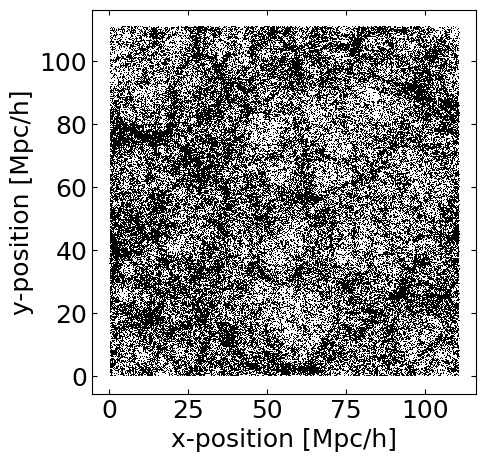

In [23]:
snaphandler.plot('pos_x','pos_y',axkws={'xlabel':'x-position [Mpc/h]','ylabel':'y-position [Mpc/h]','aspect':'equal'},plotkws={'marker':',','color':'k'})

This plots all halos x- and y-positions. Because the box is thick in the z-direction 
as well, it can result in a very dense looking plot. We can get around this by restricting
the set of halos we use:

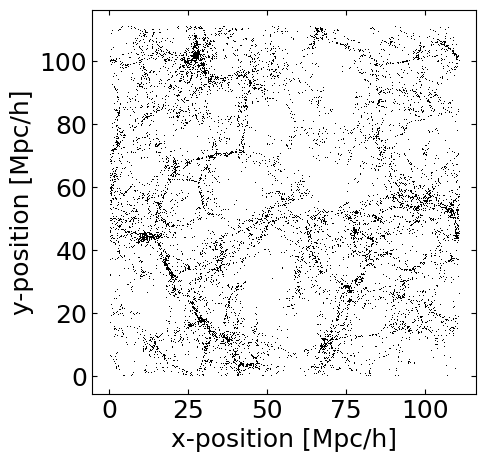

In [24]:
snaphandler.set_property_range('pos_z',0,10) # Restrict catalog to only halos with pos_z<10 Mpc/h
snaphandler.plot('pos_x','pos_y',axkws={'xlabel':'x-position [Mpc/h]','ylabel':'y-position [Mpc/h]','aspect':'equal'},plotkws={'marker':',','color':'k'})

To undo this restriction, simpy call ``set_property_range`` with no arguments. 
Note that by default ``set_property_range`` will overwrite the last set of 
restrictions set, so calling ``set_property_range('pos_x',0,10)`` followed by 
``set_property_range('pos_y',0,10)`` would result in the halo catalog being
restricted only along the y-direction and not the x direction:

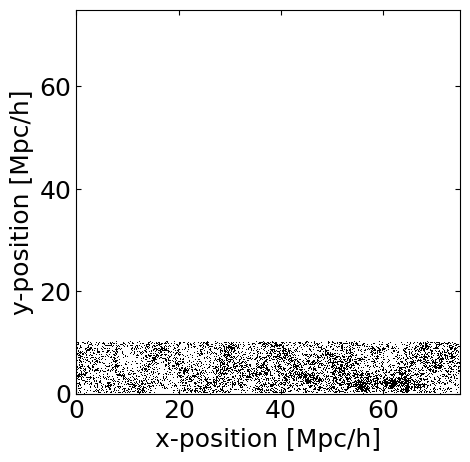

In [25]:
snaphandler.set_property_range('pos_x',0,10) # Restrict catalog to only halos with pos_x<10 Mpc/h
snaphandler.set_property_range('pos_y',0,10) # Restrict catalog to only halos with pos_y<10 Mpc/h
snaphandler.plot('pos_x','pos_y',axkws={'xlabel':'x-position [Mpc/h]','ylabel':'y-position [Mpc/h]','aspect':'equal','xlim':[0,75],'ylim':[0,75]},plotkws={'marker':',','color':'k'})

To apply multiple cuts, set the ``reset`` parameter to ``False``:

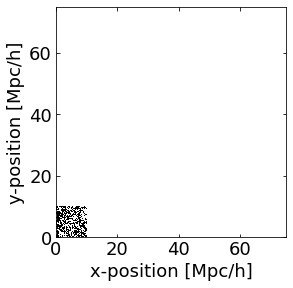

In [19]:
snaphandler.set_property_range('pos_x',0,10) # Restrict catalog to only halos with pos_x<10 Mpc/h
snaphandler.set_property_range('pos_y',0,10,reset=False) # Restrict catalog to only halos with pos_y<10 Mpc/h
snaphandler.plot('pos_x','pos_y',axkws={'xlabel':'x-position [Mpc/h]','ylabel':'y-position [Mpc/h]','aspect':'equal','xlim':[0,75],'ylim':[0,75]},plotkws={'marker':',','color':'k'})

In [20]:
# Undo these cuts.
snaphandler.set_property_range()

We can also make histograms. Here we'll plot the distribution of halo masses
in our catalog. We can see that below a mass of about $10^{10}$ $M_\odot$ the
low mass resolution of the TNG100-3 simulation results in a sharp fall off of the 
number of halos.

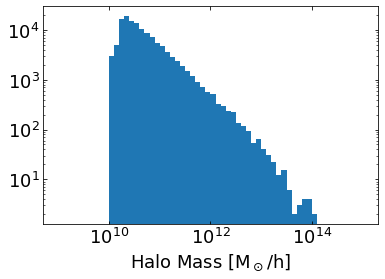

In [21]:
snaphandler.hist('mass',axkws={'xlabel':'Halo Mass [M$_\odot$/h]','xscale':'log','yscale':'log'}, plotkws={'bins':np.logspace(9,15,61)})

Note that we never loaded the 'mass' property. The snap handler will load
(and then unload) the property automatically when it is needed to execute a 
method call.

## Adding Properties to Simulations

Because TNG100-3-Dark is a dark matter only simulation, it doesn't include
important properties for our modeling, such as star formation rates. We will
need to add these ourselves. 

SimIM handles adding new properties to snapshots (and other objects like lightcones)
using the ``lineprops`` module. The key element of this module is the ``property`` 
class, which contains some function for generating a field in the halo catalog, 
given some existing halo catalog fields, along with some basic instructions for how 
to execute the function.

The ``lineprops`` module has a number of pre-defined properties, and we will
work with a few of those first before seeing how to construct new ones.

Let's start by assigning star formation rates to each halo. To do this we will
use the prescription of Behroozi et al. 2013, which is built into the ``lineprops``
module:

In [22]:
# Load the Behroozi et al. halo mass to SFR prescription
from simim.lineprops.lineprops import prop_behroozi_sfr

Adding this property to our halo catalog is very simple:

In [23]:
snaphandler.make_property(prop_behroozi_sfr)

'sfr' will now appear in the list of properties associated with the snapshot. 
Note that it has been added to the list of loaded fields and the list of newly generated
fields for the snapshot, but not to the list of fields saved to the disk. If we 
want to, we can save our new property using the command ``snaphandler.write_property('sfr')``.
However, doing so would write the property for only a single snapshot, rather than
the whole simulation, which is not what we want in this case. We will revisit adding 
properties to whole simulations in a moment.

In [24]:
print("The loaded fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='loaded')]))
print("The saved fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='saved')]))
print("The new fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='generated')]))

The loaded fields for this snapshot are: pos_x, pos_y, pos_z, sfr
The saved fields for this snapshot are: cm_x, cm_y, cm_z, mass, mass_maxr, pos_x, pos_y, pos_z, r_hm, r_vmax, spin_x, spin_y, spin_z, v_x, v_y, v_z, vdisp, vmax
The new fields for this snapshot are: sfr


Of more direct interest for intensity mapping studies are line luminosities. We can often
assign the luminosity of a given spectral line to a halo using a prescription of the form
$$\log L_\mathrm{line} = a\log\mathrm{SFR}+b$$
where $a$ and $b$ are an emperically determined coeficients of a power law fit. Typically,
some scatter is also added around this mean relation. 

Fits for the [CII] line have been presented multiple places in the literature. One example
is the work of DeLooze et al. 2014, which provides fits for multiple far infrared lines and
multiple galaxy populations. This prescription is also built in to ``lineprops``, and we 
can add it to our halos as follows:

In [25]:
from simim.lineprops.lineprops import prop_delooze_cii
snaphandler.make_property(prop_delooze_cii,rename='LCII')

By default, prop_delooze_cii uses the fit for the whole galaxy sample presented in DeLooze et al.
However, we can also use the fit for only starburst galaxies. To do this, we need to specify a 
few parameters when calling the ``make_property`` method. The ``other_kws`` parameter is a dictionary
of keyword arguments that are passed directly to the function call that generates the property -
in this case, ``set='starbursts'`` will be passed to the function underlying ``prop_delooze_cii``.
Because we already assigned the property 'LCII' (the default property name for ``prop_delooze_cii``),
we also have to specify a new property name using the ``rename`` parameter.

In [26]:
snaphandler.make_property(prop_delooze_cii,other_kws={'set':'starbursts'},rename='LCII_sb')

In [27]:
print("The loaded fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='loaded')]))
print("The saved fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='saved')]))
print("The new fields for this snapshot are: "+', '.join([f for f in snaphandler.extract_keys(set='generated')]))

The loaded fields for this snapshot are: pos_x, pos_y, pos_z, sfr, LCII, LCII_sb
The saved fields for this snapshot are: cm_x, cm_y, cm_z, mass, mass_maxr, pos_x, pos_y, pos_z, r_hm, r_vmax, spin_x, spin_y, spin_z, v_x, v_y, v_z, vdisp, vmax
The new fields for this snapshot are: sfr, LCII, LCII_sb


Now we can compare the luminosities generated by the two prescriptions:

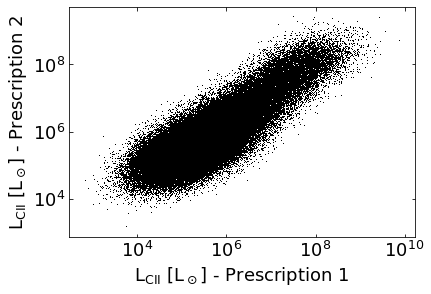

In [28]:
snaphandler.plot('LCII','LCII_sb',axkws={'xlabel':'L$_\mathregular{CII}$ [L$_\odot$] - Prescription 1',
                                         'ylabel':'L$_\mathregular{CII}$ [L$_\odot$] - Prescription 2',
                                         'xscale':'log','yscale':'log'},
                                  plotkws={'marker':',','color':'k'})

Note that there is quite a bit of scatter between the two prescriptions. Both prescriptions add a random
scatter to the luminosity of every halo, but as it stands we have not done anything to make sure that the
same halos are scattered in the same way (i.e. fixed the seed for our random number generator). Let's fix
this.

/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/_handlers.py:248: UserWarning: Property LCII already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/_handlers.py:248: UserWarning: Property LCII_sb already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))


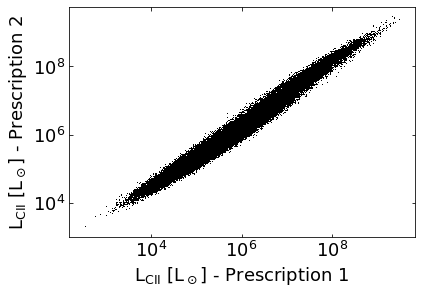

In [29]:
rng = np.random.default_rng(85712)
snaphandler.make_property(prop_delooze_cii,rename='LCII',other_kws={'rng':rng},overwrite=True)
rng = np.random.default_rng(85712) # Reseed the RNG to get the same numbers for the second application
snaphandler.make_property(prop_delooze_cii,other_kws={'rng':rng,'set':'starbursts'},rename='LCII_sb',overwrite=True)

snaphandler.plot('LCII','LCII_sb',axkws={'xlabel':'L$_\mathregular{CII}$ [L$_\odot$] - Prescription 1',
                                         'ylabel':'L$_\mathregular{CII}$ [L$_\odot$] - Prescription 2',
                                         'xscale':'log','yscale':'log'},
                                  plotkws={'marker':',','color':'k'})

This clearly reduces the scatter between the two prescriptions. Some dispersion 
remains, because the amplitude of the random scatter added by the two prescriptions
differs, but this should be a better starting point for making an apples-to-apples
comparisons between results found using the different models.

Now let's implement a ``property`` instance for a prescription not already
included in SimIM and apply it to the snapshot. 

We'll use the scaling relation fit by Schaerer et al. 2020 using the z~4-6
galaxies from the ALPINE survey. We begin by defining a unction to assign
a CII luminosity from a given SFR using the Schaerer fit plus a lognormal scatter
of 0.3 dex:

In [30]:
def lcii_schaerer(sfr,scatter_dex=0.3,rng=np.random.default_rng()):

    # Determine mean luminosity from Schaerer fit:
    a = 1.17
    b = 6.61
    lcii = 10**(a*np.log10(np.array(sfr))+b)

    # Add a lognormal scatter
    lcii = lcii / 10**(scatter_dex**2 * np.log(10)/2) # Adjustment required to preserve linear mean
    lcii = lcii * 10**(scatter_dex*rng.normal(loc=0,scale=1,size=lcii.shape))

    return lcii

Now we can wrap this function in a ``prop`` class that supplys some 
additional information needed by the snap handler to evaluate it. In particular,
we will give a default property name, a list of snapshot properties to be passed
in the function call (in this case just 'sfr'), the units of the resulting 
property ($L_\odot$), the dependence of the property on the Hubble parameter,
and whether the arguments fed to the function call (SFRs) are expected to have
units with little h (they are not) and the values returned by the function call have
units with little h (again they do not). All of this little h accounting is
because most simulations work with at least some properties in little h units,
and keeping these can be useful for translating between different cosmologies.
But in most cases similar to correlating SFRs and line luminosities we do not 
need the little h units, by default the ``prop`` class will assume no h dependence
and that all arguments and returns are in units free of the tyrany of this horrible
constant (https://arxiv.org/abs/1308.4150).

In [31]:
from simim.lineprops.lineprops import prop

prop_schaerer_cii = prop(prop_name='LCII',
                         prop_function=lcii_schaerer,
                         kwargs=['sfr'],
                         units='Lsun',
                         h_dependence=-2,
                         give_args_in_h_units=False,
                         function_return_in_h_units=False)


From here we can use the new ``prop`` instance in exactly the same manner as we did previously:

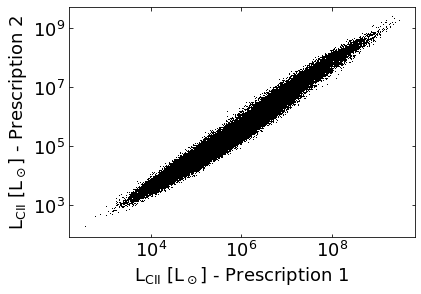

In [32]:
rng = np.random.default_rng(85712) # Reseed the RNG again
snaphandler.make_property(prop_schaerer_cii,other_kws={'rng':rng},rename='LCII_z5')

snaphandler.plot('LCII','LCII_z5',axkws={'xlabel':'L$_\mathregular{CII}$ [L$_\odot$] - Prescription 1',
                                         'ylabel':'L$_\mathregular{CII}$ [L$_\odot$] - Prescription 2',
                                         'xscale':'log','yscale':'log'},
                                  plotkws={'marker':',','color':'k'})

## Interacting with a Simulation Across All Snapshots
Now that we've seen the basics of how adding properties to snapshots works,
we can go about adding properties to the entire simulation. This is valuable
for assessing the evolution of properties with time, and is also necessary
if we want to add new properties to the simulations that can be inherited by
light cones we generate.

The sim handler has methods for handling this - essentially just wrappers
that iterate over each snapshot. We will add SFRs, and our three $L_\mathrm{CII}$
prescriptions to the whole simulation. In the following, our method calls are
similar to those used earlier, but the additional argument ``write=True`` will
save the new properties we generate to the disk, making them useable again in
the future.

In [38]:
rng1 = np.random.default_rng(80108)
simhandler.make_property(prop_behroozi_sfr,other_kws={'rng':rng1},write=True,overwrite=True)


rng2 = np.random.default_rng(85712)
simhandler.make_property(prop_delooze_cii,other_kws={'rng':rng2},rename='LCII',write=True,overwrite=True)
rng2 = np.random.default_rng(85712)
simhandler.make_property(prop_delooze_cii,other_kws={'set':'starbursts','rng':rng2},rename='LCII_sb',write=True,overwrite=True)
rng2 = np.random.default_rng(85712)
simhandler.make_property(prop_schaerer_cii,other_kws={'rng':rng2},rename='LCII_z5',write=True,overwrite=True)

/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/_handlers.py:248: UserWarning: Property sfr already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/lineprops/sfr.py:135: UserWarning: redshift exceeds maximum in Behroozi model range
  warnings.warn('redshift exceeds maximum in Behroozi model range')
/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/siminterface/simhandler.py:237: UserWarning: Property sfr already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/_handlers.py:299: UserWarning: Property sfr already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(property_name))


Assigning props for Snapshot 99.  
Assigning props for Snapshot 99.  


/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/_handlers.py:248: UserWarning: Property LCII_sb already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/siminterface/simhandler.py:237: UserWarning: Property LCII_sb already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/_handlers.py:299: UserWarning: Property LCII_sb already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(property_name))


Assigning props for Snapshot 99.  


/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/_handlers.py:248: UserWarning: Property LCII_z5 already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/siminterface/simhandler.py:237: UserWarning: Property LCII_z5 already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(name))
/Users/rpkeenan/Dropbox/4_research/2.1_simim/simim/_handlers.py:299: UserWarning: Property LCII_z5 already exists, overwriting
  warnings.warn("Property {} already exists, overwriting".format(property_name))


Assigning props for Snapshot 99.  


Now that we've constructed our properties, let's use then to assess the evolution of 
some properties of interest over cosmic history. We'll start with the cosmic star
formation rate density:

In [39]:
# Function to compute the SFRD
def sfrdensity(sfr,box_edge,h):
    return np.sum(sfr)/(box_edge/h)**3

# 'box_edge', and 'h' are two special keywords that handler objects recognize
# corresponding to the side length of the box and little h
sfrdensity_val, redshift = simhandler.snap_stat(stat_function=sfrdensity,
                                                kwargs=['sfr','box_edge','h'])

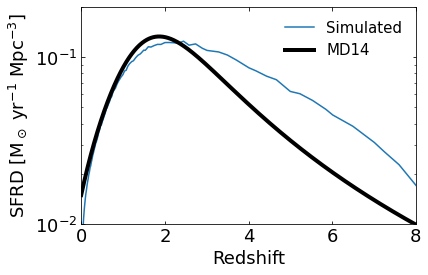

In [40]:
# We'll compare this result to the fit from Madau & Dickinson 2014
redshift_madau = np.linspace(0,10,1000)
sfrdensity_madau = 0.015 * (1+redshift_madau)**2.7 / (1+((1+redshift_madau)/2.9)**5.6)

# Plot the stuff
import matplotlib.pyplot as plt
fig,ax = plt.subplots()
ax.set(xlabel='Redshift',ylabel=r'SFRD [M$_\odot$ yr$^{-1}$ Mpc$^{-3}$]',yscale='log',xlim=[0,8],ylim=[.01,.2])
ax.plot(redshift,sfrdensity_val,color='C0',label='Simulated')
ax.plot(redshift_madau,sfrdensity_madau,color='k',ls='-',lw=4,label='MD14')
ax.legend(fontsize='small')
plt.show()


We can see that our model's SFRD deviates considerably from the fit to data from Madau and Dickinson 2014. 
These deviations are primarily at z>3, which is not of great relevance for simulating TIM, but may be 
worth understanding more fully in the future.

We can also compute quantities like average [CII] intensity and the [CII] shot noise
as a function of redshift for our various models. These quantity will be relevant for 
forecasting intensity mapping results.

In [41]:
# Function to compute the CII intensity
def mean_cii_intensity(lcii,redshift,cosmo,box_edge,h):

    wl_cii = 157.74093e-6                           # wavelength in meters
    d = cosmo.comoving_distance(redshift).value     # comoing distance at z in Mpc
    dl = (1+redshift)*d                             # luminosity distance to z in Mpc
    y = wl_cii * (1+redshift)**2 / (1000*cosmo.H(redshift).value)  # derivative of distance with respect to frequency in Mpc / Hz

    e_cii = np.sum(lcii)/(box_edge/h)**3            # in Lsun/Mpc^3
    s_cii = e_cii / (4*np.pi*dl**2) * d**2 * y      # in Lsun / Mpc^2 * Mpc^2/Sr * Mpc/Hz
    s_cii = s_cii * 3.828e26                        # in W / Sr / Mpc^2 / Hz
    s_cii = s_cii / (3.0857e22)**2                  # in W / Sr / m^2 / Hz
    s_cii = 1e26 * s_cii                            # in Jy/Sr

    return s_cii

# Function to compute the CII shot power
def cii_shot_noise(lcii,redshift,cosmo,box_edge,h):

    wl_cii = 157.74093e-6                           # wavelength in meters
    d = cosmo.comoving_distance(redshift).value     # comoing distance at z in Mpc
    dl = (1+redshift)*d                             # luminosity distance to z in Mpc
    y = wl_cii * (1+redshift)**2 / (1000*cosmo.H(redshift).value)  # derivative of distance with respect to frequency in Mpc / Hz

    e2_cii = np.sum(lcii**2)/(box_edge/h)**3            # in Lsun^2/Mpc^3
    s2_cii = e2_cii / ((4*np.pi*dl**2))**2 * (d**2 * y)**2   # in Lsun^2/Mpc^3 / Mpc^4 * Mpc^4/Sr^2 * Mpc^2/Hz^2 = Lsun^2/Sr^2/Hz^2 / Mpc 
    s2_cii = s2_cii * 3.828e26**2                       # in W^2/Sr^2/Hz^2 / Mpc = W^2/Sr^2/Hz^2 / Mpc^4 * Mpc^3
    s2_cii = s2_cii / (3.0857e22)**4                    # in W^2/Sr^2/Hz^2/m^4 * Mpc^3
    s2_cii = 1e26**2 * s2_cii                           # in Jy^2/Sr^2 Mpc^3
    s2_cii = s2_cii * h**3                              # in Jy^2/Sr^2 (Mpc/h)^3

    return s2_cii


In [42]:
# 'redshift, 'box_edge', and 'h' are all special keywords that handler objects recognize
# corresponding to the side length of the box and little h
scii_val, redshift = simhandler.snap_stat(stat_function=mean_cii_intensity,
                                          kwargs=['lcii','redshift','box_edge','h','cosmo'],
                                          kw_remap={'lcii':'LCII'})
scii_val_sb, redshift = simhandler.snap_stat(stat_function=mean_cii_intensity,
                                          kwargs=['lcii','redshift','box_edge','h','cosmo'],
                                          kw_remap={'lcii':'LCII_sb'})
scii_val_z5, redshift = simhandler.snap_stat(stat_function=mean_cii_intensity,
                                          kwargs=['lcii','redshift','box_edge','h','cosmo'],
                                          kw_remap={'lcii':'LCII_z5'})
s2cii_val, redshift = simhandler.snap_stat(stat_function=cii_shot_noise,
                                          kwargs=['lcii','redshift','box_edge','h','cosmo'],
                                          kw_remap={'lcii':'LCII'})
s2cii_val_sb, redshift = simhandler.snap_stat(stat_function=cii_shot_noise,
                                          kwargs=['lcii','redshift','box_edge','h','cosmo'],
                                          kw_remap={'lcii':'LCII_sb'})
s2cii_val_z5, redshift = simhandler.snap_stat(stat_function=cii_shot_noise,
                                          kwargs=['lcii','redshift','box_edge','h','cosmo'],
                                          kw_remap={'lcii':'LCII_z5'})

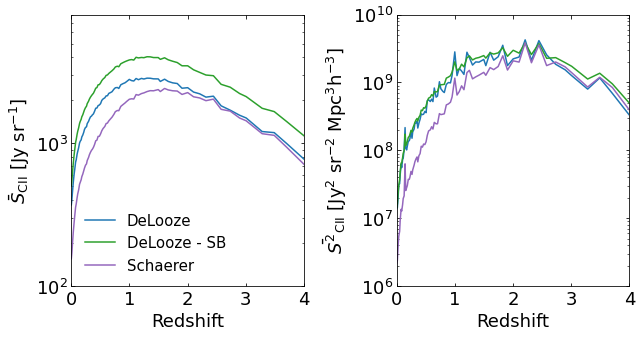

In [43]:
# Plot the stuff
fig,ax = plt.subplots(1,2,figsize=(10,5))
fig.subplots_adjust(wspace=.4)
ax[0].set(xlabel='Redshift',ylabel=r'$\bar{S}_\mathregular{CII}$ [Jy sr$^{-1}$]',yscale='log',xlim=[0,4],ylim=[1e2,8e3])
ax[0].plot(redshift,scii_val,color='C0',label='DeLooze')
ax[0].plot(redshift,scii_val_sb,color='C2',label='DeLooze - SB')
ax[0].plot(redshift,scii_val_z5,color='C4',label='Schaerer')
ax[0].legend(fontsize='small')

ax[1].set(xlabel='Redshift',ylabel=r'$\bar{S^2}_\mathregular{CII}$ [Jy$^2$ sr$^{-2}$ Mpc$^3$h$^{-3}$]',yscale='log',xlim=[0,4],ylim=[1e6,1e10])
ax[1].plot(redshift,s2cii_val,color='C0',label='DeLooze')
ax[1].plot(redshift,s2cii_val_sb,color='C2',label='DeLooze - SB')
ax[1].plot(redshift,s2cii_val_z5,color='C4',label='Schaerer')
plt.show()


## Making Light Cones
One final task is to transform our simulation boxes into lighcones with realistic
survey geometries and the apropriate sample variance and redshift evolution. These
are useful for creating mocks observations and generating test data for reduction
pipelines.

In [44]:
import simim.lightcone as lc

gen = lc.make.lightcone(sim='TNG100-3-Dark', 
                        name="demo_lc",
                        openangle = 0.1*np.pi/180,
                        aspect = 1,
                        mode = 'box',
                        redshift_min = 0.5,
                        redshift_max = 1.7,
                        minimum_mass = 1e8)
gen.build_lightcones(n=1)
gen.add_properties(keys=['sfr'])


Generating lines of sight.
Creating files and adding metadata.
Timer: WHOLE THING! took 1.552643246000116s                        
Timer: SNAPSHOT 67 took 0.005067643000074895s
Timer: SNAPSHOT 66 took 0.0052866169999106205s
Timer: SNAPSHOT 65 took 0.006467791999966721s
Timer: SNAPSHOT 64 took 0.004611514999851352s
Timer: SNAPSHOT 63 took 0.0052433190003284835s
Timer: SNAPSHOT 62 took 0.005479497000123956s
Timer: SNAPSHOT 61 took 0.004675254999710887s
Timer: SNAPSHOT 60 took 0.005127766999976302s
Timer: SNAPSHOT 59 took 0.004609610999978031s
Timer: SNAPSHOT 58 took 0.005367141000533593s
Timer: SNAPSHOT 57 took 0.004932410999572312s
Timer: SNAPSHOT 56 took 0.0044409339998310315s
Timer: SNAPSHOT 55 took 0.00444172300012724s
Timer: SNAPSHOT 54 took 0.004961989000548783s
Timer: SNAPSHOT 53 took 0.004397810000227764s
Timer: SNAPSHOT 52 took 0.005189102999793249s
Timer: SNAPSHOT 51 took 0.005151151999598369s
Timer: SNAPSHOT 50 took 0.004373867000140308s
Timer: SNAPSHOT 49 took 0.0054825530005